Información del dataset:
{'python_class': 'BreastMNIST', 'description': 'The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.', 'url': 'https://zenodo.org/records/10519652/files/breastmnist.npz?download=1', 'MD5': '750601b1f35ba3300ea97c75c52ff8f6', 'url_64': 'https://zenodo.org/records/10519652/files/breastmnist_64.npz?download=1', 'MD5_64': '742edef2a1fd1524b2efff4bd7ba9364', 'url_128': 'https://zenodo.org/records/10519652/files/breastmnist_128.npz?download=1', 'MD5_128': '363e4b3f8d712e9b5de15470a2aaadf1', 'url_224': 'https://zenodo.org/records/10519652/files/breastmnist_224.npz?downl

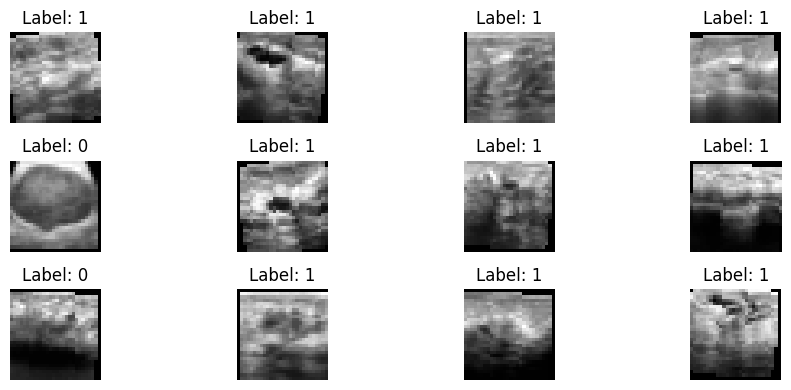

Epoch 01/20 | Loss=0.6036 | Val Acc=0.7308 | Val AUC=0.7494
Epoch 02/20 | Loss=0.4983 | Val Acc=0.3333 | Val AUC=0.7168
Epoch 03/20 | Loss=0.5214 | Val Acc=0.2692 | Val AUC=0.7477
Epoch 04/20 | Loss=0.4654 | Val Acc=0.3333 | Val AUC=0.7343
Epoch 05/20 | Loss=0.4747 | Val Acc=0.2692 | Val AUC=0.8379
Epoch 06/20 | Loss=0.4568 | Val Acc=0.2692 | Val AUC=0.8538
Epoch 07/20 | Loss=0.4580 | Val Acc=0.2692 | Val AUC=0.8496
Epoch 08/20 | Loss=0.4462 | Val Acc=0.3205 | Val AUC=0.8580
Epoch 09/20 | Loss=0.4614 | Val Acc=0.3974 | Val AUC=0.8655
Epoch 10/20 | Loss=0.4542 | Val Acc=0.5256 | Val AUC=0.8705
Epoch 11/20 | Loss=0.4696 | Val Acc=0.7051 | Val AUC=0.8780
Epoch 12/20 | Loss=0.4549 | Val Acc=0.7179 | Val AUC=0.8789
Epoch 13/20 | Loss=0.4475 | Val Acc=0.7564 | Val AUC=0.8814
Epoch 14/20 | Loss=0.4503 | Val Acc=0.8077 | Val AUC=0.8814
Epoch 15/20 | Loss=0.4606 | Val Acc=0.7949 | Val AUC=0.8814
Epoch 16/20 | Loss=0.4622 | Val Acc=0.8205 | Val AUC=0.8780
Epoch 17/20 | Loss=0.4721 | Val Acc=0.83

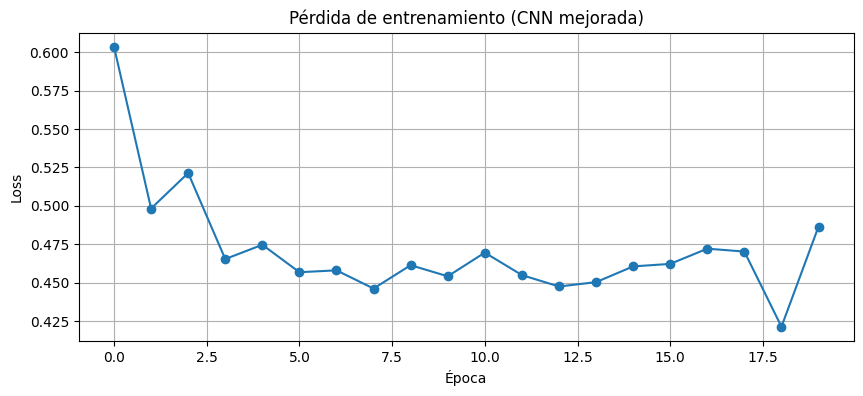

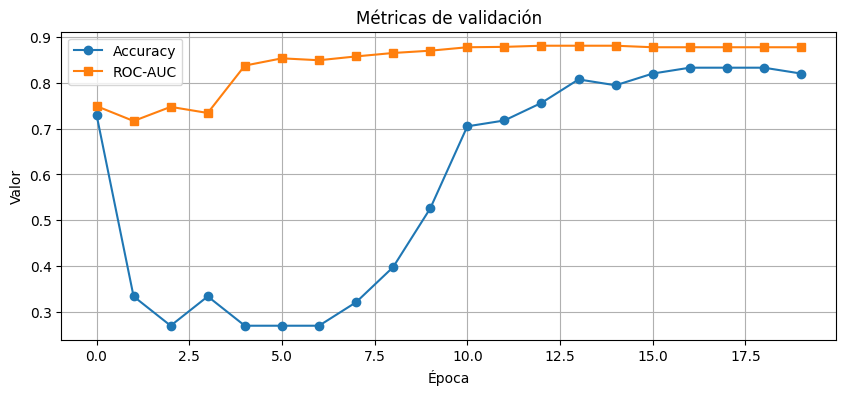


=== RESULTADOS TEST ===
Accuracy: 0.8333
ROC-AUC:  0.8252
              precision    recall  f1-score   support

           0       0.79      0.52      0.63        42
           1       0.84      0.95      0.89       114

    accuracy                           0.83       156
   macro avg       0.81      0.74      0.76       156
weighted avg       0.83      0.83      0.82       156



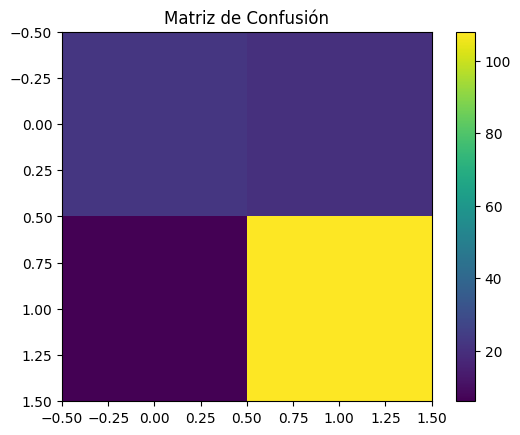

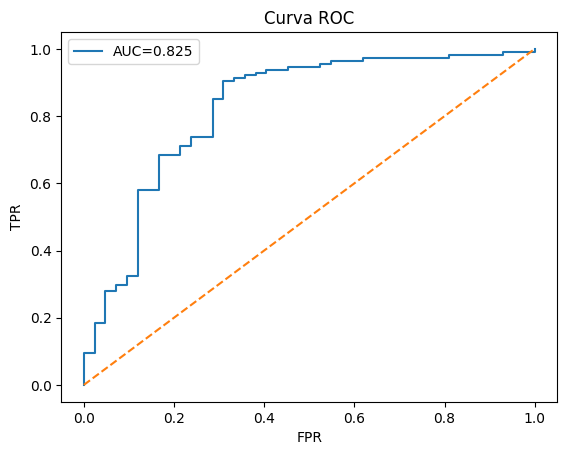

In [18]:
# =========================================
# 0. INSTALACIÓN
# =========================================
import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "medmnist"])

# =========================================
# 1. IMPORTS
# =========================================
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt

import medmnist
from medmnist import INFO

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc

# =========================================
# 2. CONFIGURACIÓN
# =========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
epochs = 20

# =========================================
# 3. DATASET (BREASTMNIST)
# =========================================
data_flag = "breastmnist"   # 🔥 CAMBIO DE DATASET
info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])

print("Información del dataset:")
print(info)

# Transforms
transform_train = T.Compose([
    T.RandomRotation(10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

transform_test = T.Compose([
    T.ToTensor()
])

# Datasets
train_dataset = DataClass(split="train", transform=transform_train, download=True)
val_dataset = DataClass(split="val", transform=transform_test, download=True)
test_dataset = DataClass(split="test", transform=transform_test, download=True)

# Loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

num_classes = len(info["label"])

# =========================================
# 3.1 VISUALIZACIÓN DE IMÁGENES DEL DATASET
# =========================================

def show_images(dataset, n=12):
    plt.figure(figsize=(10, 4))

    for i in range(n):
        x, y = dataset[i]

        plt.subplot(3, 4, i+1)
        img = x.squeeze(0)  # eliminar canal

        plt.imshow(img, cmap="gray")
        plt.title(f"Label: {int(y.item())}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Mostrar ejemplos del dataset
print("\nEjemplos del dataset:")
show_images(train_dataset)

# =========================================
# 4. MODELO CNN MEJORADO
# =========================================
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = ImprovedCNN(num_classes).to(device)

# =========================================
# 5. FUNCIONES
# =========================================
def logits_to_probs(logits):
    return torch.softmax(logits, dim=1)[:,1]  # válido para binario

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return np.mean(losses)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels, all_probs, all_preds = [], [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc_score = roc_auc_score(y_true, y_prob)

    return acc, auc_score, y_true, y_pred, y_prob

# =========================================
# 6. ENTRENAMIENTO
# =========================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

history = {"loss": [], "val_acc": [], "val_auc": []}

for epoch in range(epochs):
    loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model, val_loader)

    scheduler.step()

    history["loss"].append(loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch+1:02d}/20 | Loss={loss:.4f} | Val Acc={val_acc:.4f} | Val AUC={val_auc:.4f}")

# =========================================
# 6.1 CURVAS DE ENTRENAMIENTO
# =========================================
plt.figure(figsize=(10, 4))
plt.plot(history["loss"], marker='o')
plt.title("Pérdida de entrenamiento (CNN mejorada)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history["val_acc"], marker='o', label="Accuracy")
plt.plot(history["val_auc"], marker='s', label="ROC-AUC")
plt.title("Métricas de validación")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.grid()
plt.show()

# =========================================
# 7. EVALUACIÓN FINAL
# =========================================
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model, test_loader)

print("\n=== RESULTADOS TEST ===")
print(f"Accuracy: {test_acc:.4f}")
print(f"ROC-AUC:  {test_auc:.4f}")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
plt.imshow(cm)
plt.title("Matriz de Confusión")
plt.colorbar()
plt.show()

# =========================================
# 8. CURVA ROC
# =========================================
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC")
plt.legend()
plt.show()

# =========================================
# 9. GUARDAR MODELO
# =========================================
torch.save(model.state_dict(), "cnn_breastmnist_20epocas.pth")